# Trial use of OpenSWPC


This notebook is designed to run on Google Colaboratory (hereafter, Colab).
Colab is widely known as a Python platform, but its backend runs Ubuntu Linux. This makes it possible to compile and run OpenSWPC, which is written in Fortran, directly on Colab.


First, let us confirm that Colab is running on Ubuntu Linux and check its system specifications. In a notebook code cell, you can execute a line as a bash command by placing `!` at the beginning of the line, or execute the entire cell as a shell script by placing the `%%shell` magic command on the first line. The following commands display information about the operating system.


In [1]:
! uname -a

Linux 16e960f579bf 6.6.122+ #1 SMP Thu Apr 30 18:17:14 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux


In [2]:
! cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


The output confirms that Colab is indeed running Linux, specifically Ubuntu 22.04 LTS.


## Installation

Running the following code installs the libraries required by OpenSWPC and compiles OpenSWPC itself. This typically takes one or two minutes. You only need to perform this step once per Colab runtime session.


In [ ]:
%%bash

# Select version from https://github.com/OpenSWPC/OpenSWPC/releases
VERSION="26.09"
#VERSION="develop"

if [ $VERSION = 'develop' ]; then
    ARCHIVE=develop.zip
    ZIP_URL=https://github.com/OpenSWPC/OpenSWPC/archive/refs/heads/${ARCHIVE}
else
    ARCHIVE=${VERSION}.zip
    ZIP_URL=https://github.com/OpenSWPC/OpenSWPC/archive/refs/tags/${ARCHIVE}
fi

# NetCDF-Fortran library
sudo apt install libnetcdff-dev &> /dev/null

if [ -e ${ARCHIVE} ]; then
   rm -f ${ARCHIVE}
fi

if [ -e OpenSWPC-${VERSION} ]; then
   rm -rf OpenSWPC-${VERSION}
   rm -rf bin example swpc.py
fi

# Obtain source code from GitHub
wget -q ${ZIP_URL}
unzip -qq ${ARCHIVE}

# Build
cd OpenSWPC-${VERSION}/src
make -s arch=ubuntu-gfortran -j

cd ../../
rm -f ${ZIP_ARCHIVE}

# Symbolic links (shortcuts)
ln -s OpenSWPC-${VERSION}/bin .
ln -s OpenSWPC-${VERSION}/example .
ln -s OpenSWPC-${VERSION}/src/tools/swpc.py .

Once the installation process is complete, the `OpenSWPC-${VERSION}` directory (`${VERSION}` is the version number specified in the script), the `bin` and `example` directories, and the `swpc.py` file should have been created.

The last three are symbolic links (shortcuts); the actual files and directories reside under `OpenSWPC-${VERSION}`.

> ⚠️ **Note**
>
> The installed libraries and OpenSWPC files are not persistent. If the runtime is automatically disconnected after a period of inactivity, all of these files will be lost. To save data, you can either download individual files from the Files pane in the left sidebar or run the following code to create a `drive` folder and mount your Google Drive. You can then copy any files you want to retain into that folder.
> ```bash
> from google.colab import drive
> drive.mount('/content/drive')
>```


## Running OpenSWPC and visualizing the results


### Running OpenSWPC


Let us run the two-dimensional P-SV code `bin/swpc_psv.x` using the example parameter file `example/input.inf` included with OpenSWPC.

The command used to run an MPI parallel program on Google Colab is `mpirun`. Because shell commands on Colab are executed with root privileges, the `-allow-run-as-root` option is required. The `--use-hwthread-cpus` option is also needed to launch multiple processes. These options may differ when you run OpenSWPC on your own computer.

The parameter file `example/input.inf` specifies that the computational domain is divided between two processes. We therefore launch two processes using the `-np 2` option.


In [4]:
%%shell

mpirun -allow-run-as-root --use-hwthread-cpus \
       -np 2 ./bin/swpc_psv.x -i example/input.inf

 NSPRM           2
 SPRM  0.100000001       4.00000000    
 STFTYPEkupper          
 NSPRM           2
 SPRM  0.100000001       4.00000000    
 STFTYPEkupper          

 ------------------------------------------------------------------------------
  SWPC_PSV version dev (post 25.05.2)
 ------------------------------------------------------------------------------


  Grid Size               :      384 x    384
  MPI Partitioning        :               2
  Total Memory Size       :           0.016  [GiB]
  Node Memory Size        :           0.008  [GiB]
  Stability  Condition c  :           0.526  (c<1)
  Wavelength Condition r  :          12.488  (r>5-10)
  Minimum velocity        :           3.122  [km/s]
  Maximum velocity        :           7.977  [km/s]
  Maximum frequency       :           0.500  [Hz]

 ------------------------------------------------------------------------------

  it=0000050, 0.011 s/loop, eta 000:00:10, ( 7.40E-02  2.83E-01 )
  it=0000100, 0.010 s/loop, eta 

During the run, information is displayed at the interval specified in the parameter file, including the computation time per time step (`s/loop`), the estimated time remaining until completion (`eta`), and the maximum amplitudes of the particle-velocity components at the ground surface ($z=0$). When the `Total time` line appears, the simulation has finished, and the output files can be found under the `out` directory.


### Visualizing the results

When `swpc_psv.x` is run with the parameter file `example/input.inf`, an `out` directory is created. Snapshot files (`*.nc`) and waveform files (`wav/*.sac`) are written to this directory.

#### Snapshots

The snapshot files are stored in NetCDF format. OpenSWPC includes a program called `read_snp.x` that reads snapshot files and exports them as visualization images. Here, we visualize the particle-velocity field and then use a tool called `ffmpeg` to convert the resulting images into a movie file.


In [5]:
%%shell
echo -n "visualizing snapshot ... "

cd out/

# snapshot visualization
# options:
#    -i         : input filename
#    -q         : quiet mode
#    -bmp       : export bitmap file (.bmp)
#    -pall      : visualization includes absorption boundary layer
#    -mul       : amplitude scaling factor (empirical)
#    -color cud : color mode. legacy or cud (color universal design)
#    -bgsat n   : change background color saturation. n=0 gives grayscale
# output files will be stored at ./${title}/psv/xz/v2/

../bin/read_snp.x -i ./swpc.psv.xz.v.nc -q \
                  -bmp -pall -mul 50 -color cud -bgsat 0

echo "done"

echo -n "creating movie file ... "

# convert snapshot bmp files into mp4-formated movie
ffmpeg -loglevel quiet \
       -i swpc/psv/xz/v2/swpc.psv.xz.v2.%6d.bmp \
       -y -qscale 0 -pix_fmt yuv420p swpc.mp4

echo "done"

visualizing snapshot ... done
creating movie file ... done


If the procedure succeeds, the file `out/swpc.mp4` will be created. This is a standard MPEG-4 movie file and can be viewed after downloading it. Here, we use the `Video` function from the `IPython` module to display it directly on Google Colab.


In [6]:
from IPython.display import Video

In [7]:
Video('out/swpc.mp4', embed=True, width=300)

The intensity of the gray background represents the velocity structure (seismic-wave velocity), and interfaces across which the velocity changes abruptly are drawn as lines. The particle-velocity amplitudes are superimposed, with the vertical component shown in orange and the horizontal component in blue. You can see seismic waves radiated from near the ground surface propagating while undergoing complex reflections and mode conversions at the ground surface and velocity discontinuities.

> 🗒️ **Tip**
>
> Earlier versions of OpenSWPC used red and green to visualize the wavefield. The legacy color scheme can still be selected with `read_snp.x`.


#### Seismic waveforms

Among the output data, seismic waveforms are stored in [SAC](https://ds.iris.edu/files/sac-manual/manual/file_format.html$0) format. Here, we use [ObsPy](https://docs.obspy.org/index.html$0), a library that can read this format directly. ObsPy is not preinstalled on Colab, so we install it using `pip`.


In [8]:
! pip --quiet install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 72.0 MB/s eta 0:00:00


Let us read and plot the vertical-component waveforms from the simulation output generated above.


/usr/local/lib/python3.13/dist-packages/obspy/io/sac/util.py:260: UserWarning: Sample spacing read from SAC file (0.099999905 when rounded to nanoseconds) was rounded of to microsecond precision (0.100000000) to avoid floating point issues when converting to sampling rate (see #3408)
  warnings.warn(msg)


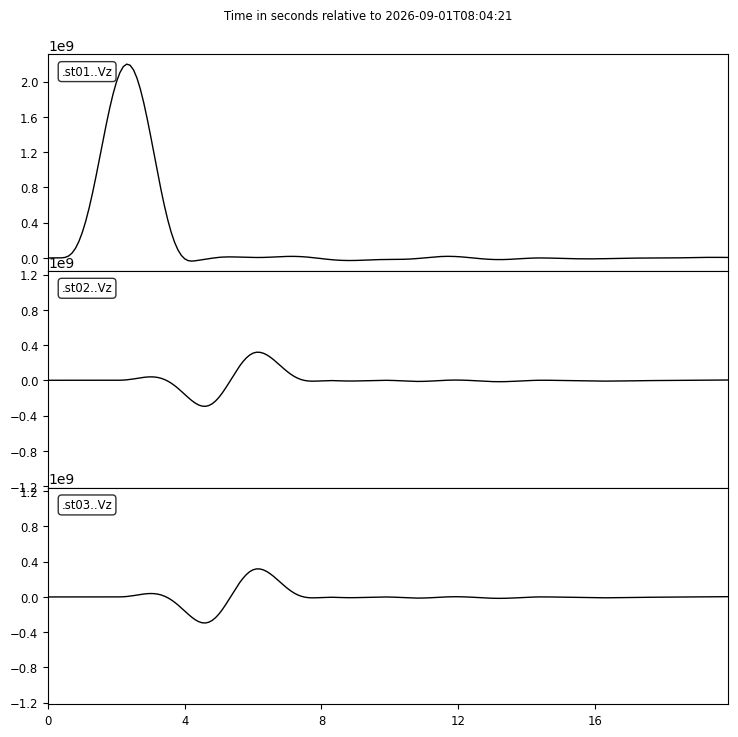

In [9]:
import obspy
stream = obspy.read('out/wav/*.Vz.sac')
stream.plot(type='relative');

> 🗒️ **Tip**
>
> You may see the following warning:
>
> `UserWarning: Sample spacing read from SAC file`
>
> This warning can safely be ignored here.


## Adjusting the parameters

The behavior of OpenSWPC is controlled by the parameter file specified when the program is run, together with configuration files referenced by that parameter file, such as those defining the source, stations, and velocity structure.

Because the parameter file is a text file, it can be created or edited directly with any text editor. OpenSWPC also includes a simple Python tool for handling parameter files. Here, we use the `swpc.py` module to modify the parameters used in the previous section.


In [10]:
# Import the module
# If swpc.py is not in the current directory,
# its location must be added to the PYTHONPATH environment variable.
import swpc


In [11]:
# Read the example parameter file
prm = swpc.prm_read('example/input.inf')


All parameters required to run OpenSWPC have now been loaded into the dictionary `prm`. Because `prm` is an ordinary Python dictionary, its values can easily be overwritten.


In [12]:
# Modify parameters
prm['title']      = 'training'            # Run title
prm['nx']         = 512                   # Number of spatial grid points
prm['nz']         = 256                   # Number of spatial grid points
prm['nt']         = 4000                  # Number of time steps
prm['xbeg']       = -50                   # Coordinate-system origin
prm['fn_lhm']     = 'example/lhm_jma.dat' # Velocity-structure file
prm['stf_format'] = 'xymwdc'              # Source format
prm['fn_stloc']   = 'example/stloc2.xy'   # Station-location file
prm['fn_stf']     = 'example/source2.dat' # Source-information file
prm['ntdec_s']    = 10                    # Snapshot output interval in time steps
prm['ntdec_r']    = 400                   # Progress-reporting interval
prm['idec']       = 1                     # Snapshot spatial decimation
prm['kdec']       = 1                     # Snapshot spatial decimation


In [13]:
# Save the parameters under a new filename
swpc.prm_save(prm, 'example/training.inf')


Here, we modify the size of the computational model, the origin of the coordinate system, the velocity-structure file, and the source and station information. See the online manual for detailed descriptions of the parameters.

These changes require two files that do not yet exist: the station-location file `stloc2.xy` and the source-information file `source2.dat`. We therefore create them below.

First, we define the stations. We place stations at regular 5-km intervals starting from $x=0$ km.


In [14]:
with open('example/stloc2.xy', 'w') as f:
    for i in range(40):
        print(f"{i*5}, 0.0, 0.0 st{i:02d} obb", file=f)

Next, we define the source. We use a source-description format based on moment magnitude $M_W$ and the strike, dip, and rake angles, and write these values to the file. See the manual for details of the source-information file format.


In [15]:
xs = 0.0
ys = 0.0 # dummy
zs = 15.0
Mw = 5.0
t0 = 0.0
trise = 2.0
strike = 0.0
dip = 45.0
rake = 90.0

with open('example/source2.dat', 'w') as f:
    print(xs, ys, zs, t0, trise, Mw, strike, dip, rake, file=f)

The setup is now complete. We can run the simulation in the same way as in the previous example.


In [19]:
%%shell

mpirun -allow-run-as-root --use-hwthread-cpus \
       -np 2 ./bin/swpc_psv.x -i example/training.inf


 ------------------------------------------------------------------------------
  SWPC_PSV version dev (post 25.05.2)
 ------------------------------------------------------------------------------


  Grid Size               :      512 x    256
  MPI Partitioning        :               2
  Total Memory Size       :           0.014  [GiB]
  Node Memory Size        :           0.007  [GiB]
  Stability  Condition c  :           0.525  (c<1)
  Wavelength Condition r  :           5.651  (r>5-10)
  Minimum velocity        :           2.826  [km/s]
  Maximum velocity        :           7.958  [km/s]
  Maximum frequency       :           1.000  [Hz]

 ------------------------------------------------------------------------------

  it=0000400, 0.014 s/loop, eta 000:00:49, ( 1.70E+01  1.87E+01 )
  it=0000800, 0.016 s/loop, eta 000:00:51, ( 7.81E+00  3.95E+00 )
  it=0001200, 0.015 s/loop, eta 000:00:42, ( 3.87E+00  4.05E+00 )
  it=0001600, 0.018 s/loop, eta 000:00:42, ( 4.05E+00  4.20E+00 )
  

For snapshots, OpenSWPC can output not only particle velocity but also displacement, as well as divergence and rotation components calculated from spatial derivatives of the particle velocity. Here, we visualize the divergence and rotation components. Because these quantities involve spatial derivatives, their amplitudes differ substantially from those of particle velocity; consequently, the appropriate value of the `-mul` option is typically about 1000 times different.


In [20]:
%%shell
echo -n "visualizing snapshot ... "

cd out/
../bin/read_snp.x -i ./training.psv.xz.ps.nc -q \
                  -bmp -pall -mul 1000 -color cud -bgsat 0

echo "done"

echo -n "creating animation file ... "

ffmpeg -loglevel quiet \
       -i training/psv/xz/ps/training.psv.xz.ps.%6d.bmp \
       -y -qscale 0 -pix_fmt yuv420p training-ps.mp4

echo "done"

visualizing snapshot ... done
creating animation file ... done


In [21]:
Video('out/training-ps.mp4', embed=True, width=600)

Because we have output seismic waveforms at many station locations, let us construct a record section. First, we read the vertical-component waveforms.


In [22]:
stream = obspy.read('out/wav/training*.Vz.sac', format='sac')

/usr/local/lib/python3.13/dist-packages/obspy/io/sac/util.py:260: UserWarning: Sample spacing read from SAC file (0.099999905 when rounded to nanoseconds) was rounded of to microsecond precision (0.100000000) to avoid floating point issues when converting to sampling rate (see #3408)
  warnings.warn(msg)


In addition to the seismic-wave amplitudes, waveform files contain header information such as station information and, in some cases, source information. In ObsPy, these values can be accessed through `.stats`.


In [23]:
stream[0].stats

         network: 
         station: st00
        location: 
         channel: Vz
       starttime: 2026-09-01T08:05:27.000000Z
         endtime: 2026-09-01T08:06:46.900000Z
   sampling_rate: 10.0
           delta: 0.1
            npts: 800
           calib: 1.0
         _format: SAC
             sac: AttribDict({'delta': np.float32(0.099999905), 'b': np.float32(0.0), 'o': np.float32(0.0), 'stla': np.float32(35.7182), 'stlo': np.float32(139.7604), 'stdp': np.float32(0.0), 'evla': np.float32(35.7182), 'evlo': np.float32(139.7604), 'evdp': np.float32(15.0), 'mag': np.float32(4.966666), 'user0': np.float32(-0.0), 'user2': np.float32(1.0), 'user4': np.float32(3.090862e-08), 'user6': np.float32(139.7604), 'user7': np.float32(35.7182), 'user8': np.float32(0.0), 'dist': np.float32(0.0), 'az': np.float32(0.0), 'baz': np.float32(0.0), 'cmpaz': np.float32(0.0), 'cmpinc': np.float32(90.0), 'nzyear': np.int32(2026), 'nzjday': np.int32(244), 'nzhour': np.int32(8), 'nzmin': np.int32(5), 'nzsec': np.

For each waveform `trace`, the epicentral distance in kilometers is stored in the `trace.stats.sac.dist` header field. However, ObsPy requires the distance in meters to be stored in `trace.stats.distance` in order to plot a record section. We therefore set this value with a simple `for` loop.


In [24]:
for trace in stream:
    trace.stats.distance = trace.stats.sac.dist * 1000

The data are now ready for a record-section plot. We plot the `stream` object using the `type='section'` option of `plot`.


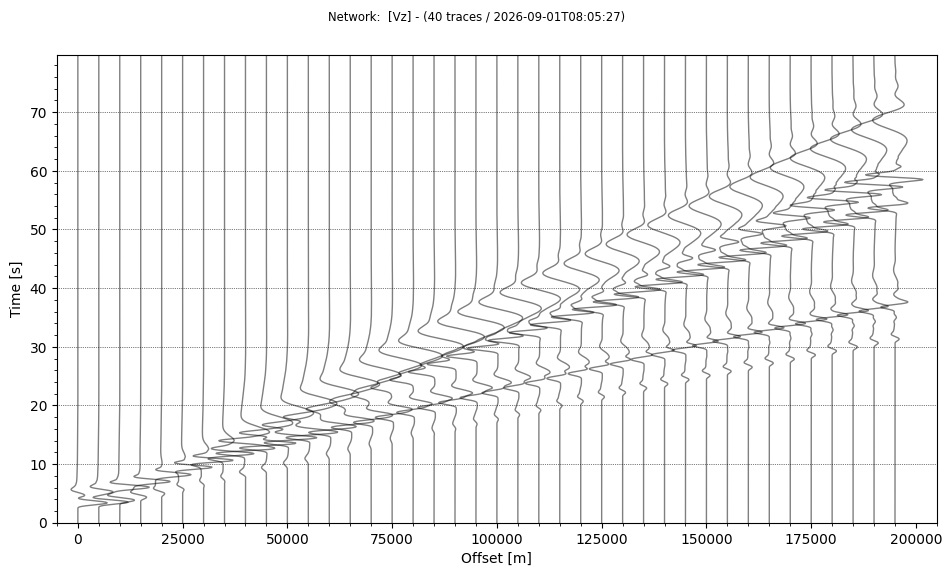

In [25]:
stream.plot(type='section', scale=2,
            offset_min = -5 * 1000, offset_max= 205 * 1000);